In [1]:
import torch
import torch.nn as nn

class StackedLSTM(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out.mean(dim=1)
        out = self.fc(out)
        return out.squeeze()   # LOGITS

[*********************100%***********************]  1 of 1 completed


  3522 trading days loaded (2010-01-04 to 2023-12-29)

  Train: 2451 days | Val: 525 days | Test: 526 days
Epoch 01 | Train 0.6332 | Val 0.6257
Epoch 02 | Train 0.6326 | Val 0.6257
Epoch 03 | Train 0.6322 | Val 0.6263
Epoch 04 | Train 0.6319 | Val 0.6267
Epoch 05 | Train 0.6316 | Val 0.6272
Epoch 06 | Train 0.6315 | Val 0.6281
Epoch 07 | Train 0.6314 | Val 0.6286
Epoch 08 | Train 0.6314 | Val 0.6293
Epoch 09 | Train 0.6315 | Val 0.6297
Epoch 10 | Train 0.6315 | Val 0.6300
Epoch 11 | Train 0.6315 | Val 0.6301
Epoch 12 | Train 0.6315 | Val 0.6299
Epoch 13 | Train 0.6314 | Val 0.6298
Epoch 14 | Train 0.6313 | Val 0.6296
Epoch 15 | Train 0.6312 | Val 0.6292
Epoch 16 | Train 0.6312 | Val 0.6291
Epoch 17 | Train 0.6312 | Val 0.6288
Epoch 18 | Train 0.6311 | Val 0.6289
Epoch 19 | Train 0.6312 | Val 0.6287
Epoch 20 | Train 0.6311 | Val 0.6287
Epoch 21 | Train 0.6311 | Val 0.6287
Epoch 22 | Train 0.6311 | Val 0.6289
Epoch 23 | Train 0.6311 | Val 0.6291
Epoch 24 | Train 0.6310 | Val 0.6293
Epoch

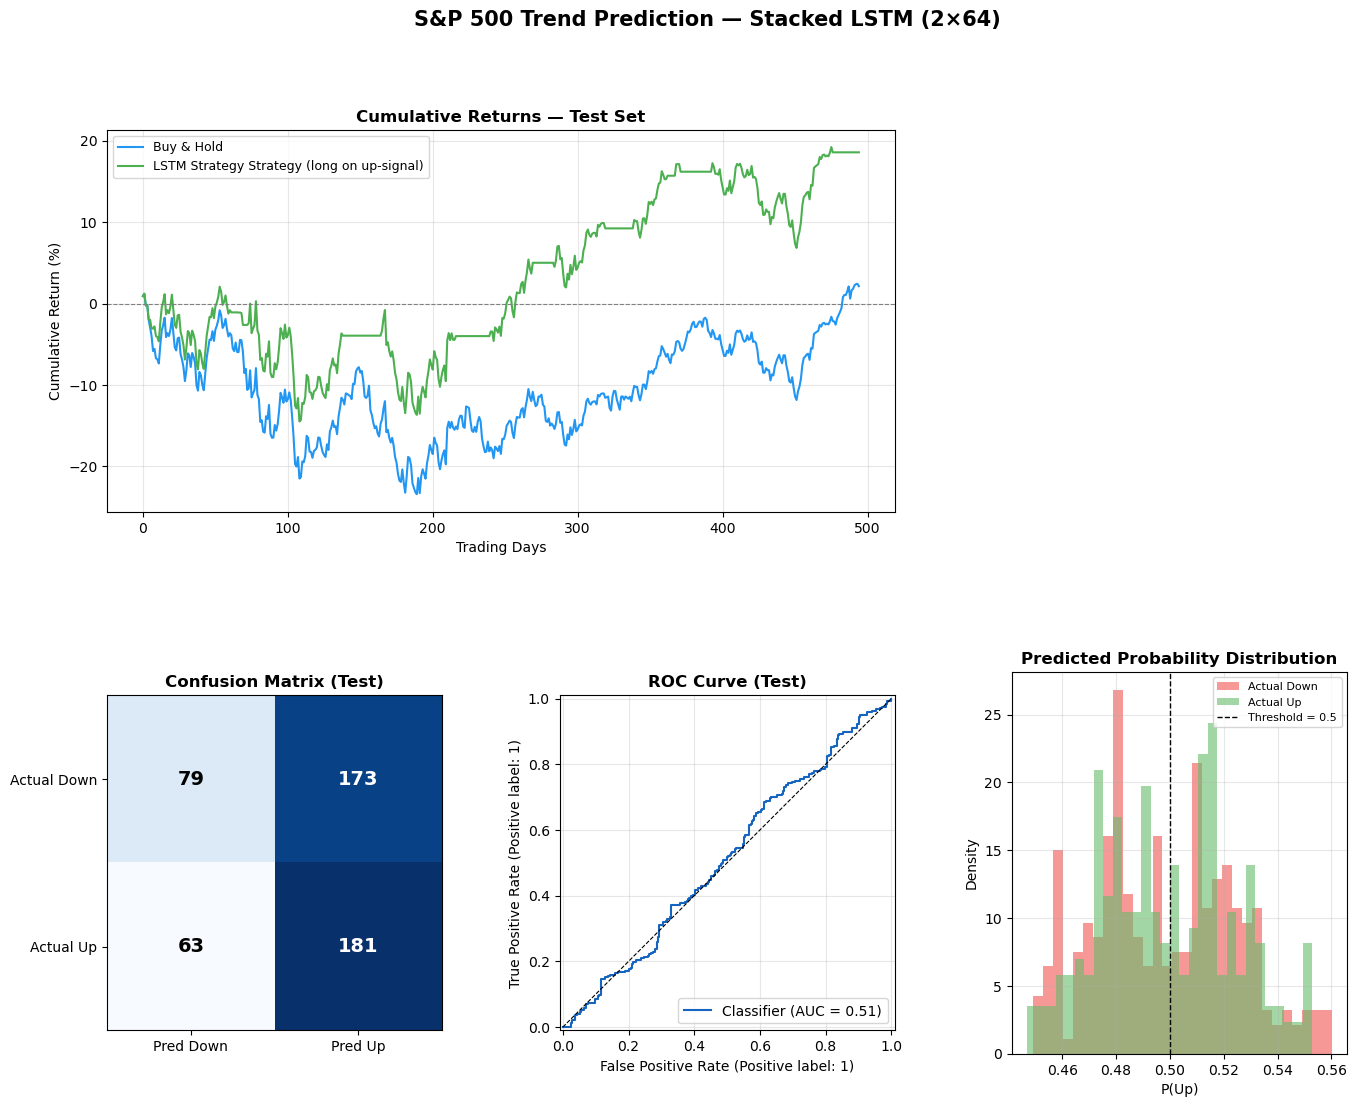

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 1. Download Data ──────────────────────────────────────────────────────────
print("Downloading S&P 500 data...")
df = yf.download("^GSPC", start="2010-01-01", end="2023-12-31", auto_adjust=True)

def make_sequences(X, y, seq_len=30):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

# Flatten MultiIndex columns returned by newer yfinance versions
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()

# Ensure all columns are 1D Series
df = df.apply(lambda col: col.squeeze())

print(f"  {len(df)} trading days loaded ({df.index[0].date()} to {df.index[-1].date()})")

# ── 2. Feature Engineering ────────────────────────────────────────────────────
def add_features(df):
    d = df.copy()

    # Returns
    d["return_1d"]  = d["Close"].pct_change(1)
    d["return_3d"]  = d["Close"].pct_change(3)
    d["return_5d"]  = d["Close"].pct_change(5)
    d["return_10d"] = d["Close"].pct_change(10)

    # Moving averages & ratio
    d["sma_5"]  = d["Close"].rolling(5).mean()
    d["sma_20"] = d["Close"].rolling(20).mean()
    d["sma_50"] = d["Close"].rolling(50).mean()
    d["price_to_sma20"] = d["Close"] / d["sma_20"]

    # Volatility
    d["volatility_10d"] = d["return_1d"].rolling(10).std()
    d["volatility_20d"] = d["return_1d"].rolling(20).std()

    # RSI (14-day)
    delta = d["Close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    d["rsi_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = d["Close"].ewm(span=12, adjust=False).mean()
    ema26 = d["Close"].ewm(span=26, adjust=False).mean()
    d["macd"]        = ema12 - ema26
    d["macd_signal"] = d["macd"].ewm(span=9, adjust=False).mean()
    d["macd_hist"]   = d["macd"] - d["macd_signal"]

    # Bollinger Band position
    bb_mid = d["Close"].rolling(20).mean()
    bb_std = d["Close"].rolling(20).std()
    d["bb_position"] = (d["Close"] - bb_mid) / (2 * bb_std)

    # Volume ratio
    d["volume_ratio"] = d["Volume"] / d["Volume"].rolling(20).mean()

    # High-Low range
    d["hl_range"] = (d["High"] - d["Low"]) / d["Close"]

    return d

df = add_features(df)

# ── 3. Target Variable ────────────────────────────────────────────────────────
df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

FEATURES = [
    "return_1d", "return_3d", "return_5d", "return_10d",
    "price_to_sma20", "volatility_10d", "volatility_20d",
    "rsi_14", "macd_hist", "bb_position", "volume_ratio", "hl_range"
]

df = df.dropna(subset=FEATURES + ["target"])

# ── 4. Train / Val / Test Split (chronological) ───────────────────────────────
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train, y_train = train[FEATURES], train["target"]
X_val,   y_val   = val[FEATURES],   val["target"]
X_test,  y_test  = test[FEATURES],  test["target"]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

X_train_seq, y_train_seq = make_sequences(X_train_s, y_train.values)
X_val_seq,   y_val_seq   = make_sequences(X_val_s, y_val.values)
X_test_seq,  y_test_seq  = make_sequences(X_test_s, y_test.values)

print(f"\n  Train: {len(train)} days | Val: {len(val)} days | Test: {len(test)} days")

# ── 5. Training and Eval ─────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
model = StackedLSTM().to(device)

ratio = (y_train_seq == 0).sum() / (y_train_seq == 1).sum()
pos_weight = torch.tensor(min(ratio, 1.5), device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(X, y):
    model.train()
    optimizer.zero_grad()
    preds = model(X)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()
    return loss.item()

Xtr = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
ytr = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
Xva = torch.tensor(X_val_seq, dtype=torch.float32).to(device)
yva = torch.tensor(y_val_seq, dtype=torch.float32).to(device)

for epoch in range(30):
    loss = train_epoch(Xtr, ytr)
    with torch.no_grad():
        val_preds = model(Xva)
        val_loss = criterion(val_preds, yva)
    print(f"Epoch {epoch+1:02d} | Train {loss:.4f} | Val {val_loss:.4f}")

# model.eval()
# with torch.no_grad():
#     val_logits = model(torch.tensor(X_val_seq, dtype=torch.float32).to(device))
#     val_probs  = torch.sigmoid(val_logits).cpu().numpy()

# thresholds = np.arange(0.40, 0.70, 0.02)

# for t in thresholds:
#     preds = (val_probs > t).astype(int)
#     f1 = f1_score(y_val_seq, preds)
#     print(f"Threshold {t:.2f} | F1 = {f1:.3f}")

best_threshold = 0.48

with torch.no_grad():
    test_logits = model(torch.tensor(X_test_seq, dtype=torch.float32).to(device))
    test_probs  = torch.sigmoid(test_logits).cpu().numpy()

test_preds = (test_probs > best_threshold).astype(int)

print(
    classification_report(
        y_test_seq,
        test_preds,
        target_names=["Down (0)", "Up (1)"]
    )
)

# ── 6. Simulated Trading Return ───────────────────────────────────────────────
test_prices = test["Close"].values[30:]
daily_returns = np.diff(test_prices) / test_prices[:-1]
signals = test_preds[:-1]
strategy_returns = np.where(signals == 1, daily_returns, 0)
bh_cumret  = np.cumprod(1 + daily_returns) - 1
strat_cumret = np.cumprod(1 + strategy_returns) - 1
print(f"\n  Buy & Hold return (test period):  {bh_cumret[-1]*100:.1f}%")
print(f"  Strategy return  (test period):   {strat_cumret[-1]*100:.1f}%")

# ── 7. Plots ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("S&P 500 Trend Prediction — Stacked LSTM (2×64)", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# (A) Cumulative returns
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(bh_cumret * 100, label="Buy & Hold", color="#2196F3", linewidth=1.5)
ax1.plot(strat_cumret * 100, label="LSTM Strategy Strategy (long on up-signal)", color="#4CAF50", linewidth=1.5)
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_title("Cumulative Returns — Test Set", fontweight="bold")
ax1.set_xlabel("Trading Days")
ax1.set_ylabel("Cumulative Return (%)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# (C) Confusion matrix
ax3 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test_seq, test_preds)
im = ax3.imshow(cm, cmap="Blues")
ax3.set_xticks([0, 1]); ax3.set_yticks([0, 1])
ax3.set_xticklabels(["Pred Down", "Pred Up"])
ax3.set_yticklabels(["Actual Down", "Actual Up"])
ax3.set_title("Confusion Matrix (Test)", fontweight="bold")
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14, fontweight="bold")

# (D) ROC Curve
ax4 = fig.add_subplot(gs[1, 1])
RocCurveDisplay.from_predictions(y_test_seq, test_probs, ax=ax4, color="#1565C0")
ax4.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax4.set_title("ROC Curve (Test)", fontweight="bold")
ax4.grid(True, alpha=0.3)

# (E) Prediction probability distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(test_probs[y_test_seq == 0], bins=30, alpha=0.6,
         color="#EF5350", label="Actual Down", density=True)
ax5.hist(test_probs[y_test_seq == 1], bins=30, alpha=0.6,
         color="#66BB6A", label="Actual Up", density=True)
ax5.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Threshold = 0.5")
ax5.set_title("Predicted Probability Distribution", fontweight="bold")
ax5.set_xlabel("P(Up)")
ax5.set_ylabel("Density")
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# plt.savefig("/home/jovyan/ECE542 Project T43/outputs/baseline_results.png", dpi=150, bbox_inches="tight")
# print("\nPlot saved.")